# HHL Linear-System Solver

This notebook executes the Harrow-Hassidim-Lloyd (HHL) algorithm for a small Hermitian positive-definite linear system as a PennyLane QNode. The circuit queues state preparation, coherent phase estimation, reciprocal-eigenvalue rotation, inverse phase estimation, and ancilla postselection.

The default path uses dense `QubitUnitary` time-evolution blocks so it can run on `default.qubit`. The same API accepts a `controlled_time_evolution` oracle hook for scalable Hamiltonian-simulation blocks; state-loading, amplitude amplification, hardware synthesis, and tomography remain problem-specific layers.


## Problem Statement

HHL solves a linear system

$$A x = b$$

by preparing a quantum state proportional to the solution vector:

$$|x\rangle = \frac{A^{-1}|b\rangle}{\|A^{-1}|b\rangle\|}.$$

Variables and assumptions:

- `A` is an `N x N` Hermitian positive-definite matrix.
- `|b>` is the normalized input state encoding the right-hand side vector `b`.
- `A = sum_j lambda_j |u_j><u_j|` is the eigendecomposition of `A`.
- `lambda_j > 0` are eigenvalues, and `|u_j>` are orthonormal eigenvectors.
- `beta_j = <u_j|b>` are the input-state amplitudes in the eigenbasis of `A`.
- The target solution state is proportional to `sum_j beta_j / lambda_j |u_j>`.


## HHL Algorithm Parameters

The finite HHL routine below uses these parameters:

- `m`: number of phase-register qubits. The phase grid has `M = 2**m` points.
- `t`: Hamiltonian simulation time in `U = exp(i A t)`.
- `phi_j = lambda_j t / (2 pi)`: phase associated with eigenvalue `lambda_j`.
- `k_j`: integer phase-register label estimating `M phi_j`.
- `tilde_lambda_j = 2 pi k_j / (M t)`: eigenvalue inferred from phase estimation.
- `C`: reciprocal-rotation scale satisfying `0 < C <= min_j tilde_lambda_j`.
- `p_success = sum_j |beta_j|**2 (C / tilde_lambda_j)**2`: probability of measuring the rotation ancilla in state `|1>`.

For this first tutorial we choose `A` and `t` so the relevant phases are exactly representable when `m = 2`. That keeps the HHL mechanism visible before introducing phase-estimation approximation error.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src" / "qsvt").exists():
    ROOT = Path.cwd().parents[0]
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from qsvt.hhl import execute_hhl_circuit
from qsvt.algorithms import (
    linear_system_comparison_summary_table,
    linear_system_comparison_workflow,
)

np.set_printoptions(precision=6, suppress=True)


def normalize(vector):
    vector = np.asarray(vector, dtype=complex)
    norm = np.linalg.norm(vector)
    if norm == 0.0:
        raise ValueError("cannot normalize the zero vector.")
    return vector / norm


def align_global_phase(reference, candidate):
    overlap = np.vdot(reference, candidate)
    if abs(overlap) == 0.0:
        return candidate
    return candidate * np.conj(overlap) / abs(overlap)


def best_scaled_residual(matrix, rhs, state):
    """Return alpha and ||A alpha|state> - rhs|| minimized over alpha."""
    A = np.asarray(matrix, dtype=complex)
    y = np.asarray(rhs, dtype=complex)
    s = normalize(state)
    As = A @ s
    denominator = np.vdot(As, As)
    if abs(denominator) == 0.0:
        raise ValueError("A @ state must be nonzero.")
    alpha = np.vdot(As, y) / denominator
    residual = A @ (alpha * s) - y
    return alpha, float(np.linalg.norm(residual))


def format_value(value):
    if value is None:
        return "-"
    if isinstance(value, (float, np.floating)):
        return f"{value:.3e}" if abs(value) < 1e-3 else f"{value:.6g}"
    if isinstance(value, (complex, np.complexfloating)):
        return f"{value.real:.6g}{value.imag:+.6g}j"
    return str(value)


def print_rows(rows, columns):
    widths = {
        column: max(
            len(column),
            *(len(format_value(row.get(column))) for row in rows),
        )
        for column in columns
    }
    print("  ".join(column.ljust(widths[column]) for column in columns))
    print("  ".join("-" * widths[column] for column in columns))
    for row in rows:
        print(
            "  ".join(
                format_value(row.get(column)).ljust(widths[column])
                for column in columns
            )
        )


## Executable HHL Circuit Update

Starting with `|b> = sum_j beta_j |u_j>`, HHL performs these conceptual steps:

1. Quantum phase estimation on `U = exp(i A t)` stores an estimate `k_j` of each eigenphase in a phase register.
2. A controlled ancilla rotation maps

   $$|k_j\rangle|0\rangle \mapsto |k_j\rangle\left(\sqrt{1 - (C / \tilde{\lambda}_j)^2}|0\rangle + (C / \tilde{\lambda}_j)|1\rangle\right).$$

3. Inverse phase estimation uncomputes the phase register.
4. Measuring the ancilla and postselecting `|1>` leaves a state proportional to

   $$\sum_j \beta_j \frac{C}{\tilde{\lambda}_j}|u_j\rangle.$$

If `tilde_lambda_j = lambda_j` for all occupied eigencomponents and the lower-bound cutoff excludes no occupied labels, this is exactly the normalized solution state.


In [2]:
def hhl_executable_circuit(
    matrix,
    rhs,
    *,
    num_phase_qubits,
    evolution_time,
    C=None,
    eigenvalue_lower_bound=None,
):
    """
    Execute HHL for a small Hermitian matrix through a PennyLane QNode.

    Dense matrix input is used only to build simulator time-evolution blocks and
    to compute classical diagnostics. The HHL state and success probability come
    from coherent QPE, controlled reciprocal rotations, inverse QPE, and
    postselection in `execute_hhl_circuit`.
    """
    A = np.asarray(matrix, dtype=complex)
    b = normalize(rhs)
    evals = np.linalg.eigvalsh(A)
    if np.any(evals <= 0.0):
        raise ValueError("HHL requires a positive spectrum in this tutorial.")

    m = int(num_phase_qubits)
    if m <= 0:
        raise ValueError("num_phase_qubits must be positive.")
    t = float(evolution_time)
    if t <= 0.0:
        raise ValueError("evolution_time must be positive.")

    phases = evals * t / (2.0 * np.pi)
    if np.any(phases >= 1.0):
        raise ValueError("choose evolution_time so lambda_max * t < 2 pi.")

    grid_size = 2**m
    phase_indices = np.floor(phases * grid_size + 0.5).astype(int)
    phase_indices = np.clip(phase_indices, 1, grid_size - 1)
    estimated_phases = phase_indices / grid_size
    estimated_evals = 2.0 * np.pi * estimated_phases / t

    if C is None:
        C = float(np.min(evals))
    C = float(C)
    if eigenvalue_lower_bound is None:
        eigenvalue_lower_bound = C
    eigenvalue_lower_bound = float(eigenvalue_lower_bound)

    circuit_result = execute_hhl_circuit(
        A,
        b,
        num_phase_qubits=m,
        evolution_time=t,
        rotation_scale_C=C,
        eigenvalue_lower_bound=eigenvalue_lower_bound,
    )
    if circuit_result.postselected_solution_state is None:
        raise RuntimeError("statevector execution is required for this tutorial.")

    hhl_state = circuit_result.postselected_solution_state
    dense_solution_state = normalize(np.linalg.solve(A, b))
    aligned_hhl_state = align_global_phase(dense_solution_state, hhl_state)
    fidelity = float(abs(np.vdot(dense_solution_state, hhl_state)) ** 2)
    state_error = float(np.linalg.norm(dense_solution_state - aligned_hhl_state))

    rotation_amplitudes = np.where(
        estimated_evals >= eigenvalue_lower_bound,
        C / estimated_evals,
        0.0,
    )

    return {
        "matrix": A,
        "rhs_state": b,
        "eigenvalues": evals,
        "num_phase_qubits": m,
        "phase_grid_size": grid_size,
        "evolution_time": t,
        "phases": phases,
        "phase_indices": phase_indices,
        "estimated_eigenvalues": estimated_evals,
        "rotation_scale_C": C,
        "eigenvalue_lower_bound": eigenvalue_lower_bound,
        "rotation_amplitudes": rotation_amplitudes,
        "success_probability": circuit_result.success_probability,
        "hhl_state": hhl_state,
        "dense_solution_state": dense_solution_state,
        "fidelity": fidelity,
        "state_error": state_error,
        "circuit_result": circuit_result,
        "truth_contract": circuit_result.as_report(),
    }


## A Two-Dimensional Test System

We use a rotated `2 x 2` matrix with eigenvalues `1` and `2`. With `t = pi / 2`, the phases are `1/4` and `1/2`, so two phase qubits represent them exactly on the grid `{0, 1/4, 1/2, 3/4}`.

This makes the first run an exact executable HHL circuit instance up to simulator floating-point roundoff.


In [3]:
theta = np.pi / 6.0
rotation = np.array(
    [
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)],
    ]
)
A = rotation @ np.diag([1.0, 2.0]) @ rotation.T
b = np.array([1.0, 0.5])

result = hhl_executable_circuit(
    A,
    b,
    num_phase_qubits=2,
    evolution_time=np.pi / 2.0,
    C=1.0,
)

print("A =")
print(np.real_if_close(A))
print("\nnormalized |b> =", np.real_if_close(result["rhs_state"]))
print("eigenvalues =", result["eigenvalues"])
print("phase indices =", result["phase_indices"])
print("estimated eigenvalues =", result["estimated_eigenvalues"])
print("rotation amplitudes C / lambda =", result["rotation_amplitudes"])
print("success probability =", result["success_probability"])
print("HHL state =", np.real_if_close(result["hhl_state"]))
print("dense solution state =", np.real_if_close(result["dense_solution_state"]))
print("state error =", result["state_error"])
print("fidelity =", result["fidelity"])


A =
[[ 1.25     -0.433013]
 [-0.433013  1.75    ]]

normalized |b> = [0.894427 0.447214]
eigenvalues = [1. 2.]
phase indices = [1 2]
estimated eigenvalues = [1. 2.]
rotation amplitudes C / lambda = [1.  0.5]
success probability = 0.9973076211353308
HHL state = [0.880635 0.473796]
dense solution state = [0.880635 0.473796]
state error = 2.2893289068207046e-16
fidelity = 0.9999999999999998


## Phase-Register Precision

The number of phase qubits controls eigenvalue precision. If `m` is too small, different eigenvalues can map to the same phase-grid label, which damages the reciprocal rotation and therefore the solution state.

The sweep below keeps `A`, `|b>`, `t`, and `C` fixed, then varies `m`.


In [4]:
sweep_rows = []
for m in range(1, 6):
    sweep_result = hhl_executable_circuit(
        A,
        b,
        num_phase_qubits=m,
        evolution_time=np.pi / 2.0,
        C=1.0,
    )
    sweep_rows.append(
        {
            "m": m,
            "grid_size": sweep_result["phase_grid_size"],
            "phase_indices": tuple(int(k) for k in sweep_result["phase_indices"]),
            "estimated_eigenvalues": tuple(
                float(x) for x in sweep_result["estimated_eigenvalues"]
            ),
            "success_probability": sweep_result["success_probability"],
            "state_error": sweep_result["state_error"],
            "fidelity": sweep_result["fidelity"],
        }
    )

print_rows(
    sweep_rows,
    [
        "m",
        "grid_size",
        "phase_indices",
        "success_probability",
        "state_error",
        "fidelity",
    ],
)


m  grid_size  phase_indices  success_probability  state_error  fidelity
-  ---------  -------------  -------------------  -----------  --------
1  2          (1, 1)         0.0631731            0.0894421    0.992016
2  4          (1, 2)         0.997308             2.289e-16    1       
3  8          (2, 4)         0.997308             1.637e-16    1       
4  16         (4, 8)         0.997308             1.121e-16    1       
5  32         (8, 16)        0.997308             1.118e-16    1       


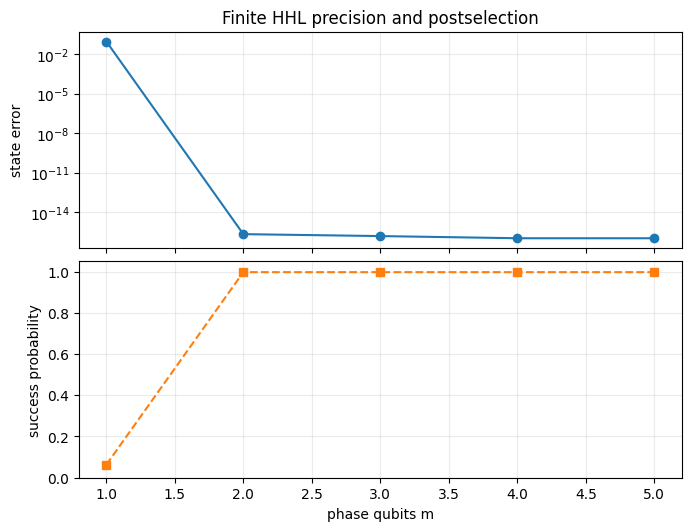

In [5]:
fig, (error_ax, success_ax) = plt.subplots(
    2,
    1,
    figsize=(6.8, 5.2),
    sharex=True,
    constrained_layout=True,
)

phase_qubits = [row["m"] for row in sweep_rows]
state_errors = [row["state_error"] for row in sweep_rows]
success_probabilities = [row["success_probability"] for row in sweep_rows]

error_ax.semilogy(phase_qubits, np.maximum(state_errors, 1e-16), "o-")
error_ax.set_ylabel("state error")
error_ax.set_title("Finite HHL precision and postselection")
error_ax.grid(True, alpha=0.25)

success_ax.plot(phase_qubits, success_probabilities, "s--", color="tab:orange")
success_ax.set_xlabel("phase qubits m")
success_ax.set_ylabel("success probability")
success_ax.set_ylim(0.0, 1.05)
success_ax.grid(True, alpha=0.25)
plt.show()


## Non-Exact Phase-Estimation Case

The first HHL run is intentionally exact on the phase grid. From this point through the comparison section, we switch to a shared harder instance `A_sweep, b_sweep`. It has eigenvalues `1` and `sqrt(2)`, and uses `t = 1.0`, so coherent phase estimation distributes amplitude over nearby binary phase-register labels.

The sweep below fixes `C = 0.75` and `eigenvalue_lower_bound = 0.75`, varies the number of phase qubits `m`, and records nearest-label diagnostics, normalized solution-state error, best-scaled residual norm, and postselection probability. The executed circuit uses coherent QPE, not a rounded spectral update, so non-grid phases may show leakage and non-monotone behavior.


In [6]:
A_sweep = rotation @ np.diag([1.0, np.sqrt(2.0)]) @ rotation.T
b_sweep = np.array([1.0, 1.0])
dense_state_sweep = normalize(np.linalg.solve(A_sweep, b_sweep))

nonexact_hhl_rows = []
nonexact_time = 1.0
nonexact_C = 0.75

for m in range(2, 9):
    nonexact = hhl_executable_circuit(
        A_sweep,
        b_sweep,
        num_phase_qubits=m,
        evolution_time=nonexact_time,
        C=nonexact_C,
    )
    _, residual_norm = best_scaled_residual(
        A_sweep,
        b_sweep,
        nonexact["hhl_state"],
    )
    nonexact_hhl_rows.append(
        {
            "m": m,
            "phase_indices": tuple(int(k) for k in nonexact["phase_indices"]),
            "estimated_eigenvalues": tuple(
                round(float(x), 6) for x in nonexact["estimated_eigenvalues"]
            ),
            "state_error": nonexact["state_error"],
            "best_scaled_residual_norm": residual_norm,
            "success_probability": nonexact["success_probability"],
        }
    )

print("A_sweep eigenvalues =", np.linalg.eigvalsh(A_sweep))
print("normalized |b_sweep> =", normalize(b_sweep))
print()
print_rows(
    nonexact_hhl_rows,
    [
        "m",
        "phase_indices",
        "estimated_eigenvalues",
        "state_error",
        "best_scaled_residual_norm",
        "success_probability",
    ],
)


A_sweep eigenvalues = [1.       1.414214]
normalized |b_sweep> = [0.707107+0.j 0.707107+0.j]

m  phase_indices  estimated_eigenvalues  state_error  best_scaled_residual_norm  success_probability
-  -------------  ---------------------  -----------  -------------------------  -------------------
2  (1, 1)         (1.570796, 1.570796)   0.168411     0.311589                   0.120052           
3  (1, 2)         (0.785398, 1.570796)   0.0286405    0.0556184                  0.634515           
4  (3, 4)         (1.178097, 1.570796)   0.0124953    0.0240983                  0.433046           
5  (5, 7)         (0.981748, 1.374447)   5.060e-04    9.780e-04                  0.556117           
6  (10, 14)       (0.981748, 1.374447)   0.00101221   0.00195697                 0.544308           
7  (20, 29)       (0.981748, 1.423534)   0.00155934   0.00301338                 0.527153           
8  (41, 58)       (1.006291, 1.423534)   0.00101394   0.0019596                  0.532957         

## Comparison To QSVT-Style Inverse

We can compare the finite HHL result with the package's QSVT-style linear-system workflow on the shared `A_sweep, b_sweep` instance. The comparison is about finite-instance behavior, not runtime.

The outputs have different natural meanings:

- HHL returns a normalized solution state extracted from the executed QNode state after phase-register uncomputation and ancilla postselection.
- The QSVT-style workflow returns a vector approximation to `A^{-1} b` and residual diagnostics.

For the state-level comparison below, both methods are compared against the normalized dense solution state. For the HHL residual, we fit the best scalar multiple `alpha |x_hhl>` before computing `||A_sweep alpha |x_hhl> - b_sweep||`.


In [7]:
hhl_comparison_result = hhl_executable_circuit(
    A_sweep,
    b_sweep,
    num_phase_qubits=8,
    evolution_time=nonexact_time,
    C=nonexact_C,
)
hhl_alpha, hhl_residual_norm = best_scaled_residual(
    A_sweep,
    b_sweep,
    hhl_comparison_result["hhl_state"],
)

qsvt_comparison = linear_system_comparison_workflow(
    A_sweep,
    b_sweep,
    degree=8,
    num_points=401,
    bounded_num_points=801,
    attempt_synthesis=False,
    apply_qsvt=False,
    include_conjugate_gradient=False,
)
qsvt_workflow = qsvt_comparison.workflow

qsvt_state = normalize(qsvt_workflow.polynomial_solution)
qsvt_state = align_global_phase(dense_state_sweep, qsvt_state)
qsvt_state_error = float(np.linalg.norm(dense_state_sweep - qsvt_state))

comparison_rows = [
    {
        "method": "HHL circuit",
        "implementation_kind": hhl_comparison_result["truth_contract"]["implementation_kind"],
        "state_error": hhl_comparison_result["state_error"],
        "success_probability": hhl_comparison_result["success_probability"],
        "residual_norm": hhl_residual_norm,
        "relative_vector_error": None,
        "phase_qubits": hhl_comparison_result["num_phase_qubits"],
        "degree": None,
        "gamma": None,
    },
    {
        "method": "QSVT-style inverse",
        "implementation_kind": "dense-spectral-polynomial-workflow",
        "state_error": qsvt_state_error,
        "success_probability": None,
        "residual_norm": qsvt_workflow.polynomial_residual_norm,
        "relative_vector_error": qsvt_workflow.polynomial_relative_error,
        "phase_qubits": None,
        "degree": qsvt_workflow.degree,
        "gamma": qsvt_workflow.gamma,
    },
]

print_rows(
    comparison_rows,
    [
        "method",
        "implementation_kind",
        "state_error",
        "success_probability",
        "residual_norm",
        "relative_vector_error",
        "phase_qubits",
        "degree",
        "gamma",
    ],
)

print("\nQSVT-style solver rows:")
print_rows(
    linear_system_comparison_summary_table(qsvt_comparison),
    ["solver", "implementation_kind", "degree", "residual_norm", "relative_solution_error"],
)


method              implementation_kind                        state_error  success_probability  residual_norm  relative_vector_error  phase_qubits  degree  gamma   
------------------  -----------------------------------------  -----------  -------------------  -------------  ---------------------  ------------  ------  --------
HHL circuit         pennylane-qnode-statevector-hhl-execution  0.00101394   0.532957             0.0019596      -                      8             -       -       
QSVT-style inverse  dense-spectral-polynomial-workflow         0.00966862   -                    0.0512108      0.0367455              -             8       0.707107

QSVT-style solver rows:
solver                         implementation_kind                 degree  residual_norm  relative_solution_error
-----------------------------  ----------------------------------  ------  -------------  -----------------------
dense_solve                    classical-dense-reference           8       0.000e+0

## HHL Phase Qubits Versus QSVT Degree

A more useful comparison sweeps each method's main accuracy knob on the same non-exact `A_sweep, b_sweep` instance. For HHL, the knob is phase-register size `m`. For the QSVT-style inverse, the knob is polynomial degree.

These curves still do not compare runtime. They compare circuit simulator diagnostics: normalized solution-state error, best-scaled HHL residual norm, HHL postselection probability, and QSVT residual norm. The side-by-side panels keep the two x-axes distinct.


In [8]:
qsvt_degree_rows = []
for degree in [4, 6, 8, 10, 12, 14]:
    degree_comparison = linear_system_comparison_workflow(
        A_sweep,
        b_sweep,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
        attempt_synthesis=False,
        apply_qsvt=False,
        include_conjugate_gradient=False,
    )
    workflow = degree_comparison.workflow
    qsvt_state = normalize(workflow.polynomial_solution)
    qsvt_state = align_global_phase(dense_state_sweep, qsvt_state)
    qsvt_degree_rows.append(
        {
            "degree": degree,
            "state_error": float(np.linalg.norm(dense_state_sweep - qsvt_state)),
            "residual_norm": workflow.polynomial_residual_norm,
            "relative_vector_error": workflow.polynomial_relative_error,
        }
    )

print("HHL non-exact phase-estimation sweep:")
print_rows(
    nonexact_hhl_rows,
    ["m", "state_error", "best_scaled_residual_norm", "success_probability"],
)
print("\nQSVT-style degree sweep:")
print_rows(
    qsvt_degree_rows,
    ["degree", "state_error", "residual_norm", "relative_vector_error"],
)


HHL non-exact phase-estimation sweep:
m  state_error  best_scaled_residual_norm  success_probability
-  -----------  -------------------------  -------------------
2  0.168411     0.311589                   0.120052           
3  0.0286405    0.0556184                  0.634515           
4  0.0124953    0.0240983                  0.433046           
5  5.060e-04    9.780e-04                  0.556117           
6  0.00101221   0.00195697                 0.544308           
7  0.00155934   0.00301338                 0.527153           
8  0.00101394   0.0019596                  0.532957           

QSVT-style degree sweep:
degree  state_error  residual_norm  relative_vector_error
------  -----------  -------------  ---------------------
4       0.00304798   0.0756114      0.052888             
6       0.00241537   0.0767715      0.0538402            
8       0.00966862   0.0512108      0.0367455            
10      0.0105851    0.049006       0.0350409            
12      0.00197623   

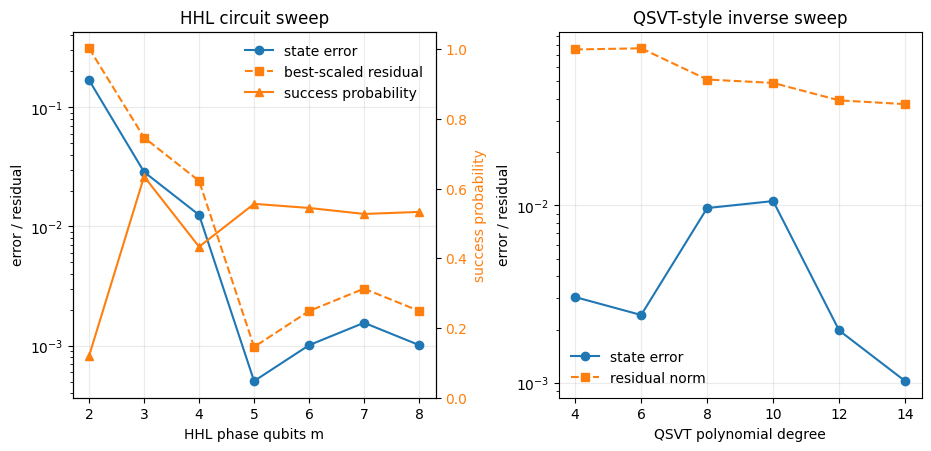

In [9]:
fig, (hhl_ax, qsvt_ax) = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.4),
    constrained_layout=True,
)

hhl_m = [row["m"] for row in nonexact_hhl_rows]
hhl_errors = [row["state_error"] for row in nonexact_hhl_rows]
hhl_residuals = [row["best_scaled_residual_norm"] for row in nonexact_hhl_rows]
hhl_success = [row["success_probability"] for row in nonexact_hhl_rows]
qsvt_degrees = [row["degree"] for row in qsvt_degree_rows]
qsvt_errors = [row["state_error"] for row in qsvt_degree_rows]
qsvt_residuals = [row["residual_norm"] for row in qsvt_degree_rows]

hhl_ax.semilogy(hhl_m, np.maximum(hhl_errors, 1e-16), "o-", label="state error")
hhl_ax.semilogy(hhl_m, np.maximum(hhl_residuals, 1e-16), "s--", label="best-scaled residual")
hhl_ax.set_xlabel("HHL phase qubits m")
hhl_ax.set_ylabel("error / residual")
hhl_ax.set_title("HHL circuit sweep")
hhl_ax.grid(True, alpha=0.25)

success_ax = hhl_ax.twinx()
success_ax.plot(hhl_m, hhl_success, "^-", color="tab:orange", label="success probability")
success_ax.set_ylim(0.0, 1.05)
success_ax.set_ylabel("success probability", color="tab:orange")
success_ax.tick_params(axis="y", labelcolor="tab:orange")

hhl_lines, hhl_labels = hhl_ax.get_legend_handles_labels()
success_lines, success_labels = success_ax.get_legend_handles_labels()
hhl_ax.legend(hhl_lines + success_lines, hhl_labels + success_labels, frameon=False)

qsvt_ax.semilogy(qsvt_degrees, np.maximum(qsvt_errors, 1e-16), "o-", label="state error")
qsvt_ax.semilogy(qsvt_degrees, np.maximum(qsvt_residuals, 1e-16), "s--", label="residual norm")
qsvt_ax.set_xlabel("QSVT polynomial degree")
qsvt_ax.set_ylabel("error / residual")
qsvt_ax.set_title("QSVT-style inverse sweep")
qsvt_ax.grid(True, alpha=0.25)
qsvt_ax.legend(frameon=False)

plt.show()


## Scope And Limitations

This notebook compares approximation behavior, not end-to-end quantum runtime. The HHL path is now an executable PennyLane circuit: it prepares `|b>`, runs coherent QPE using controlled time-evolution blocks, applies controlled reciprocal rotations with a lower-bound cutoff, uncomputes the phase register, and extracts the postselected solution state. The default dense time-evolution blocks are simulator-scale; scalable use requires supplying problem-specific sparse Hamiltonian-simulation oracles through `controlled_time_evolution`.

The QSVT-style path applies a dense spectral polynomial inverse workflow. It reports polynomial degree, state error, residual norm, and relative vector error, but this notebook does not synthesize a complete block-encoding circuit.

Two HHL-specific caveats are worth keeping in mind: choose `t` so that `lambda_max * t < 2 pi` to avoid phase aliasing, and choose the reciprocal-rotation scale `C` with the smallest resolved eigenvalue in mind because it directly affects postselection probability.


## Relation To QSVT Linear Solvers

HHL and QSVT use different primitives for the inverse map. HHL estimates eigenvalues with phase estimation and applies a reciprocal rotation. QSVT applies a bounded polynomial approximation to an inverse-like function through a block encoding.

For fair comparisons in this repository, track different quantities:

- HHL: phase qubits `m`, simulation time `t`, rotation scale `C`, solution-state error, and postselection probability.
- QSVT: polynomial degree, lower spectral bound `gamma`, boundedness/compatibility diagnostics, residual norm, and block-encoding assumptions.

Both paths still require problem-specific state preparation, scalable block encoding or Hamiltonian simulation, success-probability management, and readout before they become end-to-end application algorithms.
